**EDA**

In [5]:
# Basic imports
import pandas as pd
import numpy as np

# Visuals
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset (upload CSV to Colab)
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()


Saving Tweets.csv to Tweets (1).csv


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


**Checking Dimensions**

In [61]:
# Check Shape and basic info
print("Number of rows and columns:", df.shape)
df.info()

Number of rows and columns: (14640, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created       

**Handling Missing Values**

In [3]:
#Count of missing values in each column
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64


In [4]:
# Drop columns with extremely large missing values
df = df.drop(columns=['airline_sentiment_gold', 'negativereason_gold', 'tweet_coord'])

# Fill missing categorical text values
df['negativereason'] = df['negativereason'].fillna("None")
df['tweet_location'] = df['tweet_location'].fillna("Unknown")
df['user_timezone'] = df['user_timezone'].fillna("Unknown")

# Fill missing numeric values
df['negativereason_confidence'] = df['negativereason_confidence'].fillna(0)

# Verify no missing values remain
df.isnull().sum()


,0
tweet_id,0
airline_sentiment,0
airline_sentiment_confidence,0
negativereason,0
negativereason_confidence,0
airline,0
name,0
retweet_count,0
text,0
tweet_created,0


**Exploring Post/Tweet Length Distributions**



count    14640.000000
mean       103.822063
std         36.277339
min         12.000000
25%         77.000000
50%        114.000000
75%        136.000000
max        186.000000
Name: tweet_length, dtype: float64


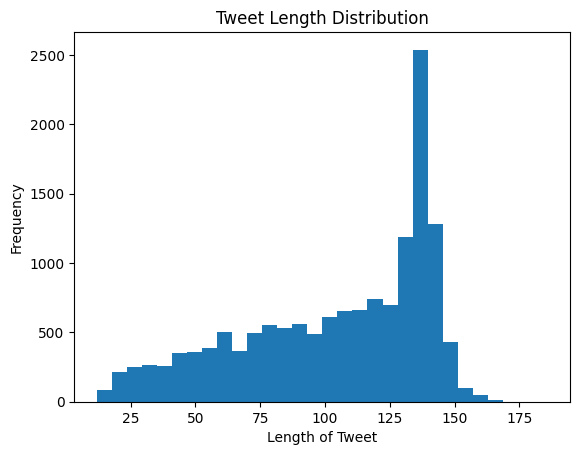

In [6]:
# Create a new column for tweet length
df['tweet_length'] = df['text'].str.len()

# Descriptive stats
print(df['tweet_length'].describe())

# Histogram of tweet lengths
import matplotlib.pyplot as plt

plt.hist(df['tweet_length'], bins=30)
plt.title("Tweet Length Distribution")
plt.xlabel("Length of Tweet")
plt.ylabel("Frequency")
plt.show()


**Label Proportions**

airline_sentiment
negative    0.626913
neutral     0.211680
positive    0.161407
Name: proportion, dtype: float64


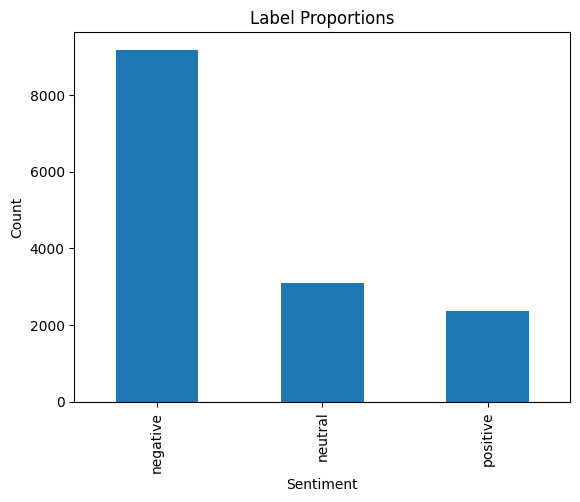

In [7]:
# Count proportions
print(df['airline_sentiment'].value_counts(normalize=True))

# Bar plot of label proportions
df['airline_sentiment'].value_counts().plot(kind='bar')
plt.title("Label Proportions")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


**TEXT VISUALIZATION**

**A.Word Clouds per Class**

In [11]:
# Importing libraries for plotting and creating word clouds
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import nltk

In [12]:
# Downloading stopwords from NLTK so common words can be ignored
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
# Cleaning tweet text by removing links, mentions, hashtags, and non-letter characters
def clean_text_for_cloud(text):
    text = re.sub(r"http\S+|[@#]\S+|[^A-Za-z\s]", "", text)
    return text.lower()


In [15]:
# Generating a word cloud from the cleaned text
def generate_wordcloud(text, title):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stop_words,
        colormap='viridis'
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()


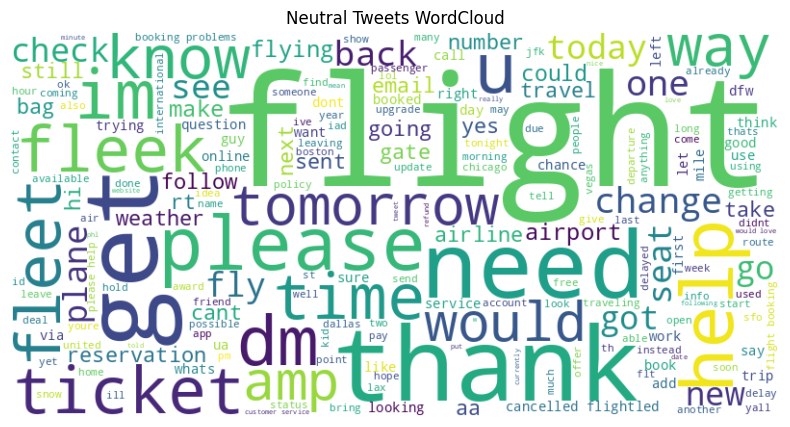

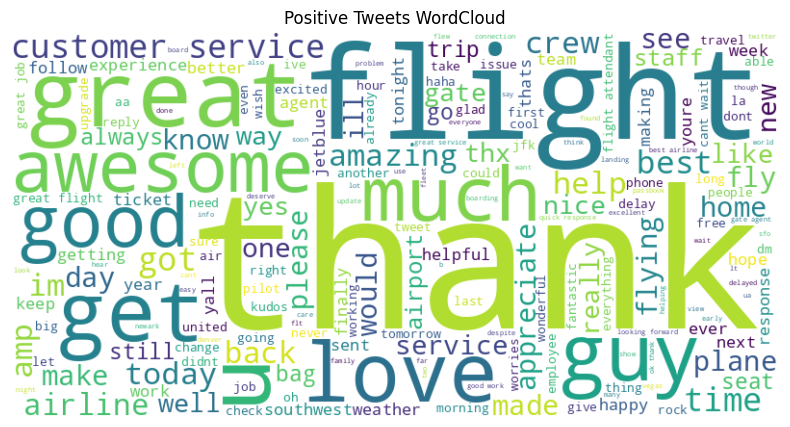

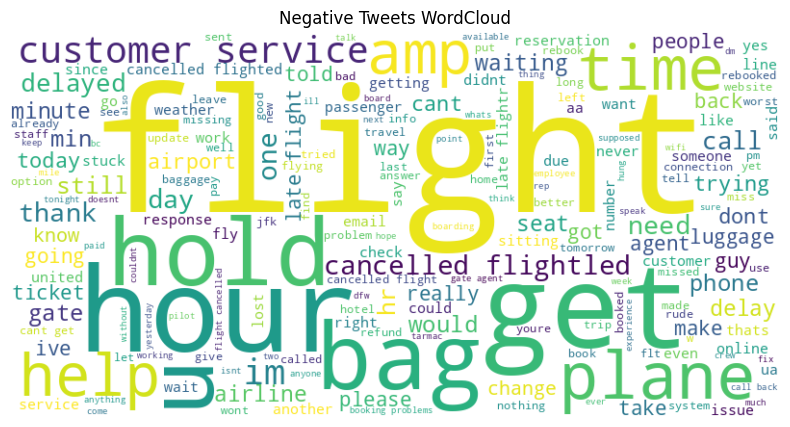

In [16]:
# Generating word clouds for each sentiment class
for sentiment in df['airline_sentiment'].unique():
    # Combining all tweets for this sentiment
    class_text = " ".join(df[df['airline_sentiment'] == sentiment]['text'].astype(str))

    # Cleaning the combined text
    cleaned_text = clean_text_for_cloud(class_text)

    # Displaying the word cloud
    generate_wordcloud(cleaned_text, f"{sentiment.capitalize()} Tweets WordCloud")

**B.Top n frequent word occurrence**

In [28]:
# Importing libraries for counting and visualizing words
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import re



In [29]:
# Tokenizing and cleaning words
def tokenize(text):
    words = text.lower().split()
    words = [w for w in words if w.isalpha() and w not in stop_words]
    return words

In [32]:
# Collecting all words from every tweet
all_words = []
for text in df["text"]:
    all_words.extend(tokenize(text))

# Counting the most common 20 words
word_frequency = Counter(all_words).most_common(20)

# Converting counts to separate lists for plotting
words, counts = zip(*word_frequency)




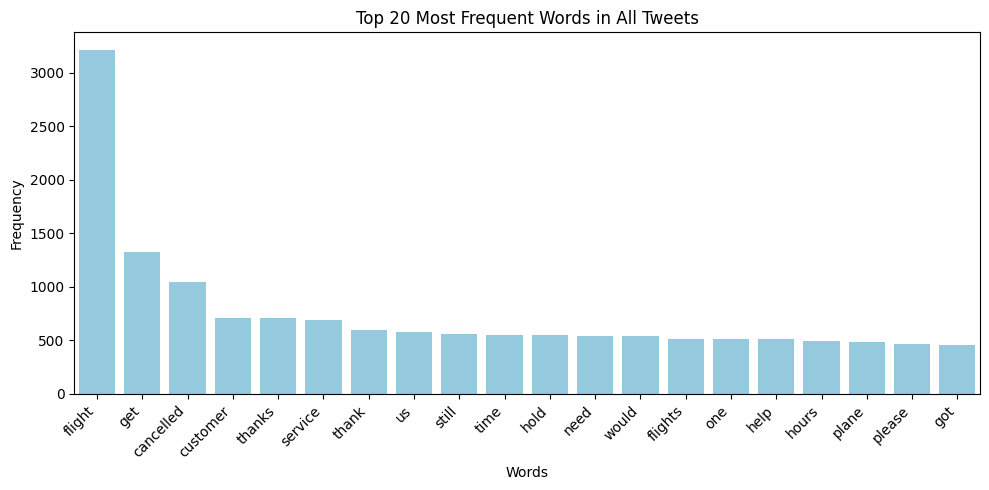

In [33]:
# Plotting the top 20 frequent words
# n=20
plt.figure(figsize=(10,5))
sns.barplot(x=list(words), y=list(counts), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Most Frequent Words in All Tweets")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**C.Tweet/post length histograms**

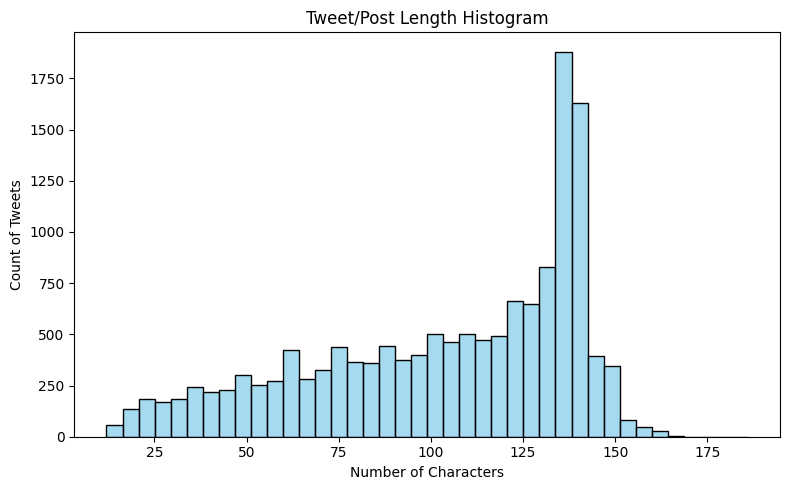

In [20]:
# Creating a column for tweet/post length
df['tweet_length'] = df['text'].str.len()

# Plotting histogram for tweet/post length
plt.figure(figsize=(8,5))
sns.histplot(df['tweet_length'], bins=40, color='skyblue', kde=False)
plt.title("Tweet/Post Length Histogram")
plt.xlabel("Number of Characters")
plt.ylabel("Count of Tweets")
plt.tight_layout()
plt.show()


**PRE PROCESSING AND FEATURE ENGINEERING**

**Cleaning and tokenizing tweets**

In [41]:
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')


# Preparing stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [43]:
# Cleaning, lowercasing, removing punctuation, stopwords, and lemmatizing
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = word_tokenize(text)
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w.isalpha() and w not in stop_words]
    return " ".join(cleaned_words)

# Applying the cleaning function to all tweets
df['clean_text'] = df['text'].apply(clean_text)

**Bag of words**

In [46]:
# Importing vectorizers for text representation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Creating Bag of Words representation
bow_vectorizer = CountVectorizer(max_features=3000)
X_bow = bow_vectorizer.fit_transform(df['clean_text'])
print("Bag of Words shape:", X_bow.shape)

Bag of Words shape: (14640, 3000)


**TF-IDF Represenation**

In [47]:
# Creating TF-IDF representation
tfidf_vectorizer = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])
print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (14640, 3000)


**MODEL BUILDING**

In [53]:
# Importing libraries for model training and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, SimpleRNN, Dense
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Splitting the TF-IDF features for the simple models
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df['airline_sentiment'], test_size=0.2, random_state=42
)


**Logistic Regression**

Logistic Regression Results
              precision    recall  f1-score   support

    negative       0.83      0.94      0.88      1889
     neutral       0.68      0.49      0.57       580
    positive       0.80      0.62      0.70       459

    accuracy                           0.80      2928
   macro avg       0.77      0.69      0.72      2928
weighted avg       0.79      0.80      0.79      2928



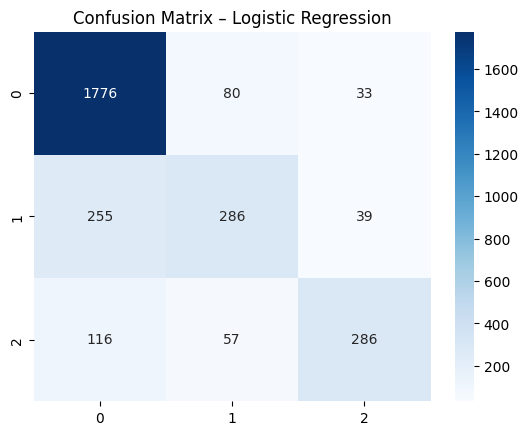

In [54]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_log))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Logistic Regression")
plt.show()


**Native Bayes**

Naive Bayes Results
              precision    recall  f1-score   support

    negative       0.75      0.98      0.85      1889
     neutral       0.73      0.29      0.42       580
    positive       0.86      0.44      0.58       459

    accuracy                           0.76      2928
   macro avg       0.78      0.57      0.62      2928
weighted avg       0.76      0.76      0.72      2928



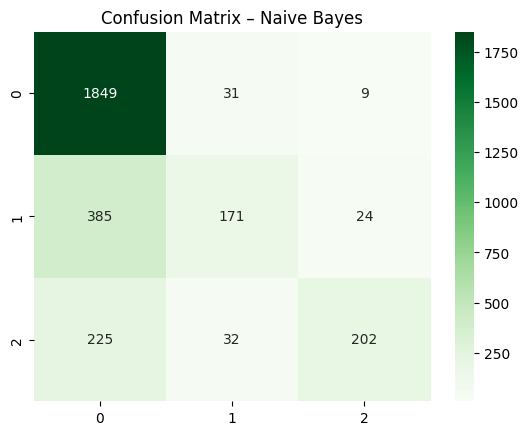

In [55]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Naive Bayes Results")
print(classification_report(y_test, y_pred_nb))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix – Naive Bayes")
plt.show()


**Preparing data for neural models (LSTM and RNN)**

**LSTM (black-box model)**

Epoch 1/3
147/147 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - accuracy: 0.6286 - loss: 0.8934 - val_accuracy: 0.7405 - val_loss: 0.6453
Epoch 2/3
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.7795 - loss: 0.5583 - val_accuracy: 0.7768 - val_loss: 0.5609
Epoch 3/3
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.8401 - loss: 0.4064 - val_accuracy: 0.7742 - val_loss: 0.5509
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
              precision    recall  f1-score   support

    negative       0.87      0.86      0.86      1889
     neutral       0.56      0.61      0.58       580
    positive       0.72      0.68      0.70       459

    accuracy                           0.78      2928
   macro avg       0.72      0.71      0.71      2928
weighted avg       0.78      0.78      0.78      2928



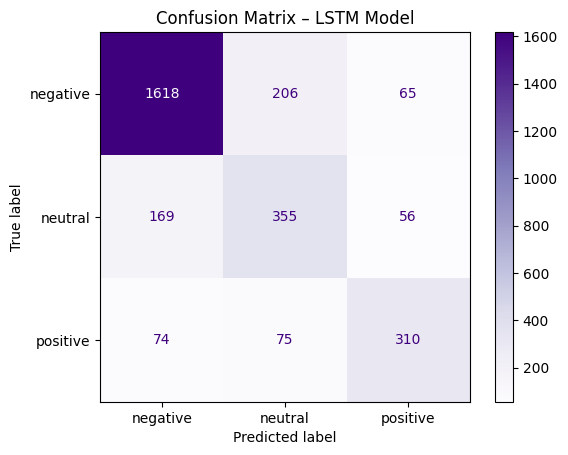

In [10]:

# --- Import libraries ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# --- Build the LSTM model ---
model_lstm = Sequential([
    Embedding(input_dim=5000, output_dim=64),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(3, activation='softmax')
])

# --- Compile and train ---
model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_lstm.fit(X_train_nn, y_train_nn, epochs=3, batch_size=64, validation_split=0.2, verbose=1)

# --- Predictions and confusion matrix ---
y_pred_lstm = np.argmax(model_lstm.predict(X_test_nn), axis=1)
print(classification_report(y_test_nn, y_pred_lstm, target_names=['negative', 'neutral', 'positive']))

cm = confusion_matrix(y_test_nn, y_pred_lstm)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'neutral', 'positive']).plot(cmap='Purples')
plt.title("Confusion Matrix – LSTM Model")
plt.show()





**RNN (black-box model)**

Epoch 1/3
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5368 - loss: 0.9978 - val_accuracy: 0.6398 - val_loss: 0.8534
Epoch 2/3
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.6650 - loss: 0.7922 - val_accuracy: 0.7153 - val_loss: 0.6864
Epoch 3/3
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7679 - loss: 0.5898 - val_accuracy: 0.7559 - val_loss: 0.6314
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
RNN Results
              precision    recall  f1-score   support

    negative       0.82      0.92      0.86      1889
     neutral       0.54      0.33      0.41       580
    positive       0.62      0.61      0.62       459

    accuracy                           0.75      2928
   macro avg       0.66      0.62      0.63      2928
weighted avg       0.73      0.75      0.74      2928



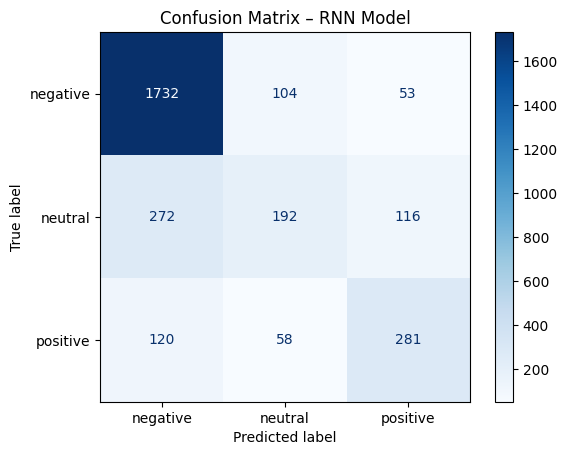

In [12]:
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense


# --- Build the RNN model ---
model_rnn = Sequential([
    Embedding(input_dim=5000, output_dim=64),
    SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(3, activation='softmax')
])

# --- Compile and train ---
model_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_rnn.fit(X_train_nn, y_train_nn, epochs=3, batch_size=64, validation_split=0.2, verbose=1)

# --- Predictions ---
y_pred_rnn = np.argmax(model_rnn.predict(X_test_nn), axis=1)

# --- Classification report ---
print("RNN Results")
print(classification_report(y_test_nn, y_pred_rnn, target_names=['negative', 'neutral', 'positive']))

# --- Confusion matrix ---
cm_rnn = confusion_matrix(y_test_nn, y_pred_rnn)
disp_rnn = ConfusionMatrixDisplay(confusion_matrix=cm_rnn, display_labels=['negative', 'neutral', 'positive'])
disp_rnn.plot(cmap='Blues')
plt.title("Confusion Matrix – RNN Model")
plt.show()


**ERROR ANALYSIS**

In [13]:
# --- Error Analysis for Misclassified Tweets ---

# Get predicted vs actual labels
y_pred_labels = np.argmax(model_lstm.predict(X_test_nn), axis=1)

# Identify misclassified indices
misclassified_indices = np.where(y_pred_labels != y_test_nn)[0]

# Convert numeric labels back to text
true_labels = label_enc.inverse_transform(y_test_nn)
pred_labels = label_enc.inverse_transform(y_pred_labels)

# Create a DataFrame to store actual vs predicted values
error_df = pd.DataFrame({
    'Tweet': [df.iloc[i]['text'] for i in misclassified_indices],
    'Actual': [true_labels[i] for i in misclassified_indices],
    'Predicted': [pred_labels[i] for i in misclassified_indices]
})

# Display 10–15 random misclassified examples
error_samples = error_df.sample(15, random_state=42)
display(error_samples)

# group by confusion type
print("\nMisclassification Summary:")
print(error_df.groupby(['Actual', 'Predicted']).size().sort_values(ascending=False).head(10))


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


,Tweet,Actual,Predicted
632,"@united yes it is partly used, the del-ewr is ...",positive,neutral
592,@United has time to respond to everyone else's...,neutral,negative
599,@united airlines.\nOn flight UA 1669.\nNeed to...,negative,neutral
291,"@united wasn't trying to Cancelled Flight, jus...",neutral,negative
72,@VirginAmerica Results Handily Exceed Forecast...,positive,negative
643,@united I think this is the best first class I...,negative,neutral
597,"@united assistance with what, the attitude of ...",neutral,negative
396,@united I unfortunately didn't get her name :(...,neutral,negative
511,@united meant changed planes - i hate seating ...,neutral,negative
174,@united But thanks for asking,negative,neutral



Misclassification Summary:
Actual    Predicted
negative  neutral      206
neutral   negative     169
positive  neutral       75
          negative      74
negative  positive      65
neutral   positive      56
dtype: int64


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('Actual').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Predicted'].value_counts()
    for x_label, grp in _df_4.groupby('Actual')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Actual')
_ = plt.ylabel('Predicted')

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_5['Actual'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_5, x='index', y='Actual', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_6['Predicted'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_6, x='index', y='Predicted', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)